# STEP 1 — Install Required Libraries

In [1]:
!pip -q install kagglehub
!pip -q install segmentation-models-pytorch
!pip -q install albumentations

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 154.8/154.8 kB 9.6 MB/s eta 0:00:00


# STEP 2 — Imports and Reproducibility Setup

In [2]:
import os
import json
import random
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from PIL import Image
import cv2

import torch
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

from tqdm.auto import tqdm

In [3]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)
torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.benchmark = True

DEVICE = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

print("Device:", DEVICE)

if torch.cuda.is_available():
    print(
        "GPU:",
        torch.cuda.get_device_name(0)
    )

Device: cuda
GPU: Tesla T4


# STEP 3 — Record Environment Versions

In [4]:
import albumentations
import segmentation_models_pytorch

print("PyTorch:", torch.__version__)
print(
    "Albumentations:",
    albumentations.__version__
)
print(
    "Segmentation Models PyTorch:",
    segmentation_models_pytorch.__version__
)
print("OpenCV:", cv2.__version__)
print("NumPy:", np.__version__)
print("Pandas:", pd.__version__)

PyTorch: 2.11.0+cu128
Albumentations: 2.0.8
Segmentation Models PyTorch: 0.5.0
OpenCV: 5.0.0
NumPy: 2.1.3
Pandas: 2.2.3


# STEP 4 — Download PlantVillage Dataset

In [5]:
import kagglehub

download_path = kagglehub.dataset_download(
    "abdallahalidev/plantvillage-dataset"
)

print(
    "Downloaded dataset path:"
)

print(download_path)

Using Colab cache for faster access to the 'plantvillage-dataset' dataset.
Downloaded dataset path:
/kaggle/input/plantvillage-dataset


# STEP 5 — Detect Dataset Root

In [6]:
base_path = Path(download_path)


def find_dataset_root(base):

    candidates = [base]

    candidates.extend(
        p
        for p in base.rglob("*")
        if p.is_dir()
    )

    for path in candidates:

        try:

            folders = {
                x.name
                for x in path.iterdir()
                if x.is_dir()
            }

            required = {
                "color",
                "grayscale",
                "segmented"
            }

            if required.issubset(
                folders
            ):
                return path

        except PermissionError:
            continue

    return None


dataset_root = find_dataset_root(
    base_path
)

print(
    "Dataset root:",
    dataset_root
)

Dataset root: /kaggle/input/plantvillage-dataset/plantvillage dataset


In [7]:
assert dataset_root is not None

assert (
    dataset_root / "color"
).exists()

assert (
    dataset_root / "segmented"
).exists()

print(
    "✅ Dataset structure found."
)

✅ Dataset structure found.


# STEP 6 — Mount Google Drive

In [8]:
from google.colab import drive

drive.mount(
    "/content/drive"
)

Mounted at /content/drive


In [9]:
PROJECT_DIR = Path(
    "/content/drive/MyDrive/"
    "PlantVillage_Segmentation"
)

print(PROJECT_DIR)

assert PROJECT_DIR.exists()

/content/drive/MyDrive/PlantVillage_Segmentation


# STEP 7 — Load Final Preprocessing Artifacts

In [10]:
FINAL_MANIFEST = (
    PROJECT_DIR /
    "final_segmentation_manifest.csv"
)

FINAL_CONFIG = (
    PROJECT_DIR /
    "segmentation_preprocessing_config.json"
)


print(
    "Manifest exists:",
    FINAL_MANIFEST.exists()
)

print(
    "Config exists:",
    FINAL_CONFIG.exists()
)

Manifest exists: True
Config exists: True


In [11]:
final_df = pd.read_csv(
    FINAL_MANIFEST
)


with open(
    FINAL_CONFIG,
    "r"
) as f:

    preprocessing_config = (
        json.load(f)
    )


print(
    "Total samples:",
    len(final_df)
)

print()

print(
    final_df[
        "split"
    ].value_counts()
)

print()

print(
    "Classes:",
    final_df[
        "class"
    ].nunique()
)

Total samples: 52969

split
train    42371
val       5300
test      5298
Name: count, dtype: int64

Classes: 38


# STEP 8 — Verify Final Preprocessing Configuration

In [12]:
BLACK_THRESHOLD = (
    preprocessing_config[
        "black_threshold"
    ]
)

IMAGE_SIZE = (
    preprocessing_config[
        "input_image_size"
    ][0]
)


print(
    "Black threshold:",
    BLACK_THRESHOLD
)

print(
    "Image size:",
    IMAGE_SIZE
)

Black threshold: 15
Image size: 256


# STEP 9 — Verify Manifest Paths

In [13]:
sample_check = final_df.sample(
    n=10,
    random_state=42
)


missing_color = 0
missing_segmented = 0


for _, row in sample_check.iterrows():

    color_path = (
        dataset_root /
        row["color_rel"]
    )

    segmented_path = (
        dataset_root /
        row["segmented_rel"]
    )


    if not color_path.exists():
        missing_color += 1


    if not segmented_path.exists():
        missing_segmented += 1


print(
    "Missing color files:",
    missing_color
)

print(
    "Missing segmented files:",
    missing_segmented
)

Missing color files: 0
Missing segmented files: 0


# STEP 10 — Final Segmentation Target Function

In [14]:
def create_final_segmentation_target(
    segmented_rgb,
    target_height,
    target_width,
    black_threshold=15
):

    """
    Create binary segmentation target
    from a QC-approved PlantVillage
    segmented RGB image.

    Background = 0
    Leaf       = 1

    No binary mask is saved to disk.
    """

    segmented_rgb = np.asarray(
        segmented_rgb,
        dtype=np.uint8
    )


    # Foreground extraction
    mask = (
        np.max(
            segmented_rgb,
            axis=2
        )
        >
        black_threshold
    ).astype(np.uint8)


    # Resize binary labels only
    # if spatial alignment is required
    if mask.shape != (
        target_height,
        target_width
    ):

        mask = cv2.resize(
            mask,
            (
                target_width,
                target_height
            ),
            interpolation=cv2.INTER_NEAREST
        )


    return mask

# STEP 11 — Define Common Data Transformations

In [15]:
train_transform = A.Compose([

    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.HorizontalFlip(
        p=0.5
    ),

    A.VerticalFlip(
        p=0.5
    ),

    A.RandomRotate90(
        p=0.5
    ),

    A.Normalize(
        mean=(
            0.485,
            0.456,
            0.406
        ),
        std=(
            0.229,
            0.224,
            0.225
        )
    ),

    ToTensorV2()
])


eval_transform = A.Compose([

    A.Resize(
        IMAGE_SIZE,
        IMAGE_SIZE
    ),

    A.Normalize(
        mean=(
            0.485,
            0.456,
            0.406
        ),
        std=(
            0.229,
            0.224,
            0.225
        )
    ),

    ToTensorV2()
])

# STEP 12 — Create Segmentation Dataset Class

In [16]:
class PlantVillageSegmentationDataset(
    Dataset
):

    def __init__(
        self,
        dataframe,
        dataset_root,
        transform=None,
        black_threshold=15
    ):

        self.df = (
            dataframe
            .reset_index(drop=True)
        )

        self.dataset_root = Path(
            dataset_root
        )

        self.transform = transform

        self.black_threshold = (
            black_threshold
        )


    def __len__(self):

        return len(self.df)


    def __getitem__(
        self,
        index
    ):

        row = self.df.iloc[index]


        color_path = (
            self.dataset_root /
            row["color_rel"]
        )


        segmented_path = (
            self.dataset_root /
            row["segmented_rel"]
        )


        # ---------------------------------
        # Model input
        # ---------------------------------

        image = np.array(
            Image.open(
                color_path
            ).convert("RGB")
        )


        # ---------------------------------
        # PlantVillage supervision source
        # ---------------------------------

        segmented = np.array(
            Image.open(
                segmented_path
            ).convert("RGB")
        )


        # ---------------------------------
        # Dynamic segmentation target
        # ---------------------------------

        mask = (
            create_final_segmentation_target(
                segmented_rgb=segmented,
                target_height=image.shape[0],
                target_width=image.shape[1],
                black_threshold=self.black_threshold
            )
        )


        # ---------------------------------
        # Joint transformations
        # ---------------------------------

        if self.transform is not None:

            transformed = (
                self.transform(
                    image=image,
                    mask=mask
                )
            )

            image = transformed[
                "image"
            ]

            mask = transformed[
                "mask"
            ]


        mask = mask.float()


        if mask.ndim == 2:

            mask = mask.unsqueeze(0)


        return {
            "image": image,

            "mask": mask,

            "class_name":
                row["class"],

            "color_rel":
                row["color_rel"],

            "segmented_rel":
                row["segmented_rel"]
        }

# STEP 13 — Create Final Dataset Splits

In [17]:
train_df = final_df[
    final_df["split"]
    ==
    "train"
].copy()


val_df = final_df[
    final_df["split"]
    ==
    "val"
].copy()


test_df = final_df[
    final_df["split"]
    ==
    "test"
].copy()


print(
    "Train:",
    len(train_df)
)

print(
    "Validation:",
    len(val_df)
)

print(
    "Test:",
    len(test_df)
)

Train: 42371
Validation: 5300
Test: 5298


In [18]:
train_dataset = (
    PlantVillageSegmentationDataset(
        dataframe=train_df,
        dataset_root=dataset_root,
        transform=train_transform,
        black_threshold=BLACK_THRESHOLD
    )
)


val_dataset = (
    PlantVillageSegmentationDataset(
        dataframe=val_df,
        dataset_root=dataset_root,
        transform=eval_transform,
        black_threshold=BLACK_THRESHOLD
    )
)


test_dataset = (
    PlantVillageSegmentationDataset(
        dataframe=test_df,
        dataset_root=dataset_root,
        transform=eval_transform,
        black_threshold=BLACK_THRESHOLD
    )
)

# STEP 14 — Create GPU DataLoaders

In [19]:
BATCH_SIZE = 16
NUM_WORKERS = 2


train_loader = DataLoader(

    train_dataset,

    batch_size=BATCH_SIZE,

    shuffle=True,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)


val_loader = DataLoader(

    val_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)


test_loader = DataLoader(

    test_dataset,

    batch_size=BATCH_SIZE,

    shuffle=False,

    num_workers=NUM_WORKERS,

    pin_memory=True,

    persistent_workers=True
)


print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

Train batches: 2649
Validation batches: 332
Test batches: 332


# STEP 15 — DataLoader Sanity Check

In [20]:
batch = next(
    iter(train_loader)
)


images = batch[
    "image"
]

masks = batch[
    "mask"
]


print(
    "Images:",
    images.shape
)

print(
    "Masks:",
    masks.shape
)

print(
    "Image dtype:",
    images.dtype
)

print(
    "Mask dtype:",
    masks.dtype
)

print(
    "Mask values:",
    torch.unique(masks)
)

Images: torch.Size([16, 3, 256, 256])
Masks: torch.Size([16, 1, 256, 256])
Image dtype: torch.float32
Mask dtype: torch.float32
Mask values: tensor([0., 1.])


# STEP 16 — GPU Batch Test

In [21]:
images_gpu = images.to(
    DEVICE,
    non_blocking=True
)

masks_gpu = masks.to(
    DEVICE,
    non_blocking=True
)


print(
    "Image device:",
    images_gpu.device
)

print(
    "Mask device:",
    masks_gpu.device
)

print(
    "GPU memory allocated (MB):",
    torch.cuda.memory_allocated()
    / 1024**2
)

Image device: cuda:0
Mask device: cuda:0
GPU memory allocated (MB): 16.0


# STEP 17 — Create U-Net Experiment Directory

In [22]:
EXPERIMENT_NAME = "UNet"

EXPERIMENT_DIR = (
    PROJECT_DIR /
    "experiments" /
    EXPERIMENT_NAME
)

EXPERIMENT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

CHECKPOINT_DIR = (
    EXPERIMENT_DIR /
    "checkpoints"
)

CHECKPOINT_DIR.mkdir(
    parents=True,
    exist_ok=True
)

RESULTS_DIR = (
    EXPERIMENT_DIR /
    "results"
)

RESULTS_DIR.mkdir(
    parents=True,
    exist_ok=True
)

PREDICTION_DIR = (
    EXPERIMENT_DIR /
    "predictions"
)

PREDICTION_DIR.mkdir(
    parents=True,
    exist_ok=True
)

print("Experiment directory:")
print(EXPERIMENT_DIR)

Experiment directory:
/content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet




```
PlantVillage_Segmentation/
└── experiments/
    └── UNet/
        ├── checkpoints/
        ├── results/
        └── predictions/
```



# STEP 18 — Build U-Net Model

In [23]:
model = smp.Unet(
    encoder_name="resnet34",
    encoder_weights="imagenet",
    in_channels=3,
    classes=1,
    activation=None
)

model = model.to(DEVICE)

print(model.__class__.__name__)

total_params = sum(
    p.numel()
    for p in model.parameters()
)

trainable_params = sum(
    p.numel()
    for p in model.parameters()
    if p.requires_grad
)

print(
    f"Total parameters: "
    f"{total_params:,}"
)

print(
    f"Trainable parameters: "
    f"{trainable_params:,}"
)

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B / 87.3MB            

model.safetensors: downloading bytes:           |  0.00B            

Unet
Total parameters: 24,436,369
Trainable parameters: 24,436,369


# STEP 19 — Save U-Net Experiment Configuration

In [24]:
UNET_CONFIG = {

    "experiment_name":
        "UNet",

    "architecture":
        "UNet",

    "encoder":
        "resnet34",

    "encoder_weights":
        "imagenet",

    "input_channels":
        3,

    "output_channels":
        1,

    "image_size":
        IMAGE_SIZE,

    "batch_size":
        BATCH_SIZE,

    "random_seed":
        SEED,

    "train_samples":
        len(train_dataset),

    "validation_samples":
        len(val_dataset),

    "test_samples":
        len(test_dataset),

    "black_threshold":
        BLACK_THRESHOLD,

    "device":
        str(DEVICE),

    "gpu":
        (
            torch.cuda.get_device_name(0)
            if torch.cuda.is_available()
            else None
        )
}


UNET_CONFIG_PATH = (
    EXPERIMENT_DIR /
    "unet_config.json"
)


with open(
    UNET_CONFIG_PATH,
    "w"
) as f:

    json.dump(
        UNET_CONFIG,
        f,
        indent=4
    )


print(
    "Saved:",
    UNET_CONFIG_PATH
)

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/unet_config.json


# STEP 20 — Define Segmentation Loss

In [25]:
bce_loss = torch.nn.BCEWithLogitsLoss()

dice_loss = smp.losses.DiceLoss(
    mode="binary",
    from_logits=True
)


def combined_loss(
    logits,
    targets
):

    bce = bce_loss(
        logits,
        targets
    )

    dice = dice_loss(
        logits,
        targets
    )

    loss = (
        0.5 * bce
        +
        0.5 * dice
    )

    return loss

# STEP 21 — Define Evaluation Metrics

In [26]:
def calculate_metrics(
    logits,
    targets,
    threshold=0.5,
    eps=1e-7
):

    probabilities = torch.sigmoid(
        logits
    )

    predictions = (
        probabilities >= threshold
    ).float()


    predictions = predictions.view(-1)
    targets = targets.view(-1)


    tp = torch.sum(
        predictions * targets
    )

    fp = torch.sum(
        predictions * (1 - targets)
    )

    fn = torch.sum(
        (1 - predictions) * targets
    )

    tn = torch.sum(
        (1 - predictions)
        * (1 - targets)
    )


    dice = (
        (2 * tp + eps)
        /
        (2 * tp + fp + fn + eps)
    )


    iou = (
        (tp + eps)
        /
        (tp + fp + fn + eps)
    )


    precision = (
        (tp + eps)
        /
        (tp + fp + eps)
    )


    recall = (
        (tp + eps)
        /
        (tp + fn + eps)
    )


    specificity = (
        (tn + eps)
        /
        (tn + fp + eps)
    )


    accuracy = (
        (tp + tn + eps)
        /
        (
            tp + tn
            + fp + fn
            + eps
        )
    )


    return {
        "dice":
            dice.item(),

        "iou":
            iou.item(),

        "precision":
            precision.item(),

        "recall":
            recall.item(),

        "specificity":
            specificity.item(),

        "accuracy":
            accuracy.item()
    }

# STEP 22 — Define Training Configuration

In [27]:
LEARNING_RATE = 1e-4
WEIGHT_DECAY = 1e-4

MAX_EPOCHS = 30

EARLY_STOPPING_PATIENCE = 7


optimizer = torch.optim.AdamW(

    model.parameters(),

    lr=LEARNING_RATE,

    weight_decay=WEIGHT_DECAY
)


scheduler = (
    torch.optim.lr_scheduler
    .ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=3
    )
)


scaler = torch.amp.GradScaler(
    "cuda",
    enabled=(
        DEVICE.type == "cuda"
    )
)


print(
    "Learning rate:",
    LEARNING_RATE
)

print(
    "Max epochs:",
    MAX_EPOCHS
)

print(
    "Early stopping patience:",
    EARLY_STOPPING_PATIENCE
)

Learning rate: 0.0001
Max epochs: 30
Early stopping patience: 7


# STEP 23 — Define Training Function

In [28]:
def train_one_epoch(
    model,
    loader,
    optimizer,
    scaler,
    device
):

    model.train()

    running_loss = 0.0

    metric_sums = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "specificity": 0.0,
        "accuracy": 0.0
    }


    progress_bar = tqdm(
        loader,
        desc="Training",
        leave=False
    )


    for batch in progress_bar:

        images = batch[
            "image"
        ].to(
            device,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            device,
            non_blocking=True
        )


        optimizer.zero_grad(
            set_to_none=True
        )


        with torch.amp.autocast(
            device_type=device.type,
            enabled=(
                device.type == "cuda"
            )
        ):

            logits = model(
                images
            )

            loss = combined_loss(
                logits,
                masks
            )


        scaler.scale(
            loss
        ).backward()


        scaler.step(
            optimizer
        )


        scaler.update()


        running_loss += (
            loss.item()
        )


        with torch.no_grad():

            metrics = (
                calculate_metrics(
                    logits,
                    masks
                )
            )


        for key in metric_sums:

            metric_sums[key] += (
                metrics[key]
            )


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{metrics['dice']:.4f}"
        )


    num_batches = len(
        loader
    )


    epoch_results = {

        "loss":
            running_loss
            /
            num_batches
    }


    for key in metric_sums:

        epoch_results[key] = (
            metric_sums[key]
            /
            num_batches
        )


    return epoch_results

# STEP 24 — Define Validation Function

In [29]:
@torch.no_grad()
def validate_one_epoch(
    model,
    loader,
    device
):

    model.eval()

    running_loss = 0.0

    metric_sums = {
        "dice": 0.0,
        "iou": 0.0,
        "precision": 0.0,
        "recall": 0.0,
        "specificity": 0.0,
        "accuracy": 0.0
    }


    progress_bar = tqdm(
        loader,
        desc="Validation",
        leave=False
    )


    for batch in progress_bar:

        images = batch[
            "image"
        ].to(
            device,
            non_blocking=True
        )

        masks = batch[
            "mask"
        ].to(
            device,
            non_blocking=True
        )


        with torch.amp.autocast(
            device_type=device.type,
            enabled=(
                device.type == "cuda"
            )
        ):

            logits = model(
                images
            )

            loss = combined_loss(
                logits,
                masks
            )


        running_loss += (
            loss.item()
        )


        metrics = (
            calculate_metrics(
                logits,
                masks
            )
        )


        for key in metric_sums:

            metric_sums[key] += (
                metrics[key]
            )


        progress_bar.set_postfix(
            loss=f"{loss.item():.4f}",
            dice=f"{metrics['dice']:.4f}"
        )


    num_batches = len(
        loader
    )


    epoch_results = {

        "loss":
            running_loss
            /
            num_batches
    }


    for key in metric_sums:

        epoch_results[key] = (
            metric_sums[key]
            /
            num_batches
        )


    return epoch_results

# STEP 25 — Train U-Net

GPU memory check

In [30]:
print(
    torch.cuda.get_device_name(0)
)

print(
    "Allocated GB:",
    torch.cuda.memory_allocated()
    / 1024**3
)

print(
    "Reserved GB:",
    torch.cuda.memory_reserved()
    / 1024**3
)

Tesla T4
Allocated GB: 0.1070713996887207
Reserved GB: 0.1171875


In [31]:
BEST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "best_unet.pth"
)

LAST_MODEL_PATH = (
    CHECKPOINT_DIR /
    "last_unet.pth"
)

HISTORY_PATH = (
    RESULTS_DIR /
    "training_history.csv"
)


history = []

best_val_dice = -1.0

epochs_without_improvement = 0


for epoch in range(
    1,
    MAX_EPOCHS + 1
):

    print(
        f"\nEpoch "
        f"{epoch}/{MAX_EPOCHS}"
    )

    print("-" * 60)


    train_results = (
        train_one_epoch(
            model=model,
            loader=train_loader,
            optimizer=optimizer,
            scaler=scaler,
            device=DEVICE
        )
    )


    val_results = (
        validate_one_epoch(
            model=model,
            loader=val_loader,
            device=DEVICE
        )
    )


    current_lr = (
        optimizer
        .param_groups[0]["lr"]
    )


    scheduler.step(
        val_results[
            "dice"
        ]
    )


    epoch_record = {

        "epoch":
            epoch,

        "learning_rate":
            current_lr,

        "train_loss":
            train_results["loss"],

        "train_dice":
            train_results["dice"],

        "train_iou":
            train_results["iou"],

        "val_loss":
            val_results["loss"],

        "val_dice":
            val_results["dice"],

        "val_iou":
            val_results["iou"],

        "val_precision":
            val_results[
                "precision"
            ],

        "val_recall":
            val_results[
                "recall"
            ],

        "val_specificity":
            val_results[
                "specificity"
            ],

        "val_accuracy":
            val_results[
                "accuracy"
            ]
    }


    history.append(
        epoch_record
    )


    # Save history every epoch
    pd.DataFrame(
        history
    ).to_csv(
        HISTORY_PATH,
        index=False
    )


    print(
        f"Train Loss : "
        f"{train_results['loss']:.4f}"
    )

    print(
        f"Train Dice : "
        f"{train_results['dice']:.4f}"
    )

    print(
        f"Train IoU  : "
        f"{train_results['iou']:.4f}"
    )

    print()

    print(
        f"Val Loss   : "
        f"{val_results['loss']:.4f}"
    )

    print(
        f"Val Dice   : "
        f"{val_results['dice']:.4f}"
    )

    print(
        f"Val IoU    : "
        f"{val_results['iou']:.4f}"
    )

    print(
        f"Val Prec.  : "
        f"{val_results['precision']:.4f}"
    )

    print(
        f"Val Recall : "
        f"{val_results['recall']:.4f}"
    )

    print(
        f"Val Spec.  : "
        f"{val_results['specificity']:.4f}"
    )

    print(
        f"Val Acc.   : "
        f"{val_results['accuracy']:.4f}"
    )


    # -----------------------------------
    # Best checkpoint
    # -----------------------------------

    if (
        val_results["dice"]
        >
        best_val_dice
    ):

        best_val_dice = (
            val_results[
                "dice"
            ]
        )

        epochs_without_improvement = 0


        torch.save(
            {
                "epoch":
                    epoch,

                "model_state_dict":
                    model.state_dict(),

                "optimizer_state_dict":
                    optimizer.state_dict(),

                "best_val_dice":
                    best_val_dice,

                "config":
                    UNET_CONFIG
            },
            BEST_MODEL_PATH
        )


        print(
            "✅ New best model saved."
        )


    else:

        epochs_without_improvement += 1


    # -----------------------------------
    # Save latest checkpoint
    # -----------------------------------

    torch.save(
        {
            "epoch":
                epoch,

            "model_state_dict":
                model.state_dict(),

            "optimizer_state_dict":
                optimizer.state_dict(),

            "best_val_dice":
                best_val_dice,

            "history":
                history
        },
        LAST_MODEL_PATH
    )


    # -----------------------------------
    # Early stopping
    # -----------------------------------

    if (
        epochs_without_improvement
        >=
        EARLY_STOPPING_PATIENCE
    ):

        print()

        print(
            "⏹️ Early stopping triggered."
        )

        break


print()
print("=" * 60)

print(
    "Training finished."
)

print(
    "Best validation Dice:",
    f"{best_val_dice:.4f}"
)

print(
    "Best checkpoint:"
)

print(
    BEST_MODEL_PATH
)


Epoch 1/30
------------------------------------------------------------


Training:   0%|          | 0/2649 [00:00<?, ?it/s]

Validation:   0%|          | 0/332 [00:00<?, ?it/s]

Train Loss : 0.0445
Train Dice : 0.9841
Train IoU  : 0.9693

Val Loss   : 0.0255
Val Dice   : 0.9882
Val IoU    : 0.9767
Val Prec.  : 0.9919
Val Recall : 0.9846
Val Spec.  : 0.9930
Val Acc.   : 0.9891
✅ New best model saved.

Epoch 2/30
------------------------------------------------------------


Training:   0%|          | 0/2649 [00:00<?, ?it/s]

...

Validation:   0%|          | 0/332 [00:00<?, ?it/s]

Train Loss : 0.0161
Train Dice : 0.9916
Train IoU  : 0.9833

Val Loss   : 0.0182
Val Dice   : 0.9910
Val IoU    : 0.9822
Val Prec.  : 0.9918
Val Recall : 0.9902
Val Spec.  : 0.9929
Val Acc.   : 0.9916

Epoch 30/30
------------------------------------------------------------


Training:   0%|          | 0/2649 [00:00<?, ?it/s]

Validation:   0%|          | 0/332 [00:00<?, ?it/s]

Train Loss : 0.0158
Train Dice : 0.9917
Train IoU  : 0.9836

Val Loss   : 0.0182
Val Dice   : 0.9910
Val IoU    : 0.9823
Val Prec.  : 0.9917
Val Recall : 0.9904
Val Spec.  : 0.9928
Val Acc.   : 0.9917

Training finished.
Best validation Dice: 0.9911
Best checkpoint:
/content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/checkpoints/best_unet.pth


# STEP 26 — Reload Best U-Net Checkpoint

In [32]:
checkpoint = torch.load(
    BEST_MODEL_PATH,
    map_location=DEVICE,
    weights_only=False
)

model.load_state_dict(
    checkpoint["model_state_dict"]
)

model = model.to(DEVICE)
model.eval()

print(
    "Best checkpoint epoch:",
    checkpoint["epoch"]
)

print(
    "Best validation Dice:",
    checkpoint["best_val_dice"]
)

print("✅ Best U-Net restored.")

Best checkpoint epoch: 26
Best validation Dice: 0.9911337333271303
✅ Best U-Net restored.


# STEP 27 — Define Final Test Evaluation

In [33]:
@torch.no_grad()
def evaluate_test_set(
    model,
    loader,
    device,
    threshold=0.5,
    eps=1e-7
):

    model.eval()

    total_loss = 0.0
    total_samples = 0

    total_tp = 0.0
    total_fp = 0.0
    total_fn = 0.0
    total_tn = 0.0


    progress_bar = tqdm(
        loader,
        desc="Testing",
        leave=False
    )


    for batch in progress_bar:

        images = batch["image"].to(
            device,
            non_blocking=True
        )

        masks = batch["mask"].to(
            device,
            non_blocking=True
        )


        with torch.amp.autocast(
            device_type=device.type,
            enabled=(device.type == "cuda")
        ):

            logits = model(images)

            loss = combined_loss(
                logits,
                masks
            )


        batch_size = images.size(0)

        total_loss += (
            loss.item()
            * batch_size
        )

        total_samples += batch_size


        probabilities = torch.sigmoid(
            logits
        )

        predictions = (
            probabilities >= threshold
        ).float()


        predictions = predictions.reshape(-1)
        targets = masks.reshape(-1)


        tp = torch.sum(
            predictions * targets
        ).item()

        fp = torch.sum(
            predictions * (1 - targets)
        ).item()

        fn = torch.sum(
            (1 - predictions) * targets
        ).item()

        tn = torch.sum(
            (1 - predictions)
            * (1 - targets)
        ).item()


        total_tp += tp
        total_fp += fp
        total_fn += fn
        total_tn += tn


    test_loss = (
        total_loss
        /
        total_samples
    )


    dice = (
        2 * total_tp + eps
    ) / (
        2 * total_tp
        + total_fp
        + total_fn
        + eps
    )


    iou = (
        total_tp + eps
    ) / (
        total_tp
        + total_fp
        + total_fn
        + eps
    )


    precision = (
        total_tp + eps
    ) / (
        total_tp
        + total_fp
        + eps
    )


    recall = (
        total_tp + eps
    ) / (
        total_tp
        + total_fn
        + eps
    )


    specificity = (
        total_tn + eps
    ) / (
        total_tn
        + total_fp
        + eps
    )


    accuracy = (
        total_tp
        + total_tn
        + eps
    ) / (
        total_tp
        + total_tn
        + total_fp
        + total_fn
        + eps
    )


    return {

        "test_loss":
            float(test_loss),

        "dice":
            float(dice),

        "iou":
            float(iou),

        "precision":
            float(precision),

        "recall":
            float(recall),

        "specificity":
            float(specificity),

        "pixel_accuracy":
            float(accuracy),

        "tp_pixels":
            int(total_tp),

        "fp_pixels":
            int(total_fp),

        "fn_pixels":
            int(total_fn),

        "tn_pixels":
            int(total_tn),

        "threshold":
            threshold
    }

# STEP 28 — Evaluate Best U-Net on the Test Set

In [34]:
test_results = evaluate_test_set(
    model=model,
    loader=test_loader,
    device=DEVICE,
    threshold=0.5
)


print("=" * 60)
print("FINAL U-NET TEST RESULTS")
print("=" * 60)

print(
    f"Test Loss       : "
    f"{test_results['test_loss']:.6f}"
)

print(
    f"Dice Score      : "
    f"{test_results['dice']:.6f}"
)

print(
    f"IoU / Jaccard   : "
    f"{test_results['iou']:.6f}"
)

print(
    f"Precision       : "
    f"{test_results['precision']:.6f}"
)

print(
    f"Recall          : "
    f"{test_results['recall']:.6f}"
)

print(
    f"Specificity     : "
    f"{test_results['specificity']:.6f}"
)

print(
    f"Pixel Accuracy  : "
    f"{test_results['pixel_accuracy']:.6f}"
)

Testing:   0%|          | 0/332 [00:00<?, ?it/s]

FINAL U-NET TEST RESULTS
Test Loss       : 0.017573
Dice Score      : 0.991319
IoU / Jaccard   : 0.982788
Precision       : 0.991544
Recall          : 0.991094
Specificity     : 0.992660
Pixel Accuracy  : 0.991933


# STEP 29 — Save Final Test Metrics

In [35]:
TEST_METRICS_PATH = (
    RESULTS_DIR /
    "test_metrics.json"
)

with open(
    TEST_METRICS_PATH,
    "w"
) as f:

    json.dump(
        test_results,
        f,
        indent=4
    )


test_metrics_df = pd.DataFrame(
    [{
        "model":
            "UNet",

        "encoder":
            "resnet34",

        "best_val_dice":
            checkpoint[
                "best_val_dice"
            ],

        **test_results
    }]
)


TEST_METRICS_CSV = (
    RESULTS_DIR /
    "test_metrics.csv"
)

test_metrics_df.to_csv(
    TEST_METRICS_CSV,
    index=False
)


print(
    "Saved JSON:",
    TEST_METRICS_PATH
)

print(
    "Saved CSV:",
    TEST_METRICS_CSV
)

Saved JSON: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/test_metrics.json
Saved CSV: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/test_metrics.csv


# STEP 30 — Load Training History

In [36]:
history_df = pd.read_csv(
    HISTORY_PATH
)

print(
    "Epochs recorded:",
    len(history_df)
)

display(
    history_df.tail()
)

Epochs recorded: 30


,epoch,learning_rate,train_loss,train_dice,train_iou,val_loss,val_dice,val_iou,val_precision,val_recall,val_specificity,val_accuracy
25,26,0.000025,0.016478,0.991431,0.983042,0.017964,0.991134,0.982472,0.991373,0.990944,0.992477,0.991776
26,27,0.000025,0.016310,0.991466,0.983112,0.019186,0.990511,0.981261,0.990459,0.990627,0.991607,0.991174
27,28,0.000025,0.016202,0.991559,0.983292,0.018321,0.990875,0.981972,0.991795,0.990016,0.992843,0.991536
28,29,0.000025,0.016101,0.991588,0.983347,0.018183,0.990970,0.982154,0.991786,0.990209,0.992853,0.991628
29,30,0.000013,0.015824,0.991707,0.983582,0.018245,0.991036,0.982283,0.991712,0.990414,0.992774,0.991685


# STEP 31 — Plot Loss Curves

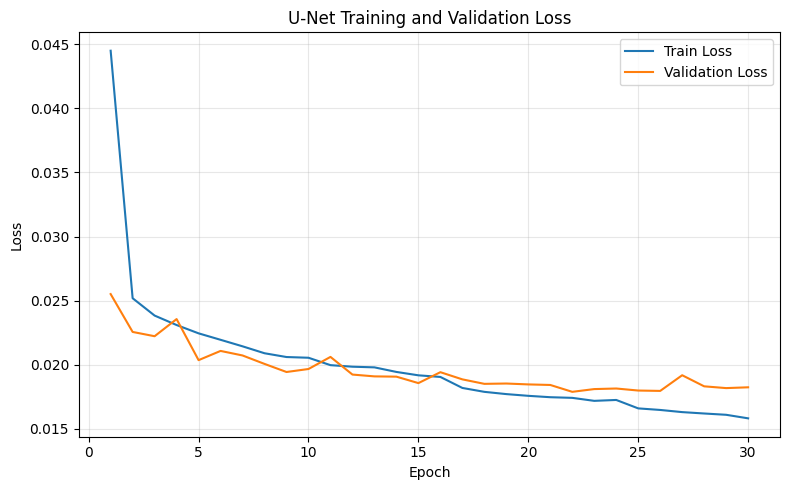

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/loss_curve.png


In [37]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_loss"],
    label="Train Loss"
)

plt.plot(
    history_df["epoch"],
    history_df["val_loss"],
    label="Validation Loss"
)

plt.xlabel("Epoch")
plt.ylabel("Loss")

plt.title(
    "U-Net Training and Validation Loss"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()


LOSS_CURVE_PATH = (
    RESULTS_DIR /
    "loss_curve.png"
)

plt.savefig(
    LOSS_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    LOSS_CURVE_PATH
)

# STEP 32 — Plot Dice Score Curves

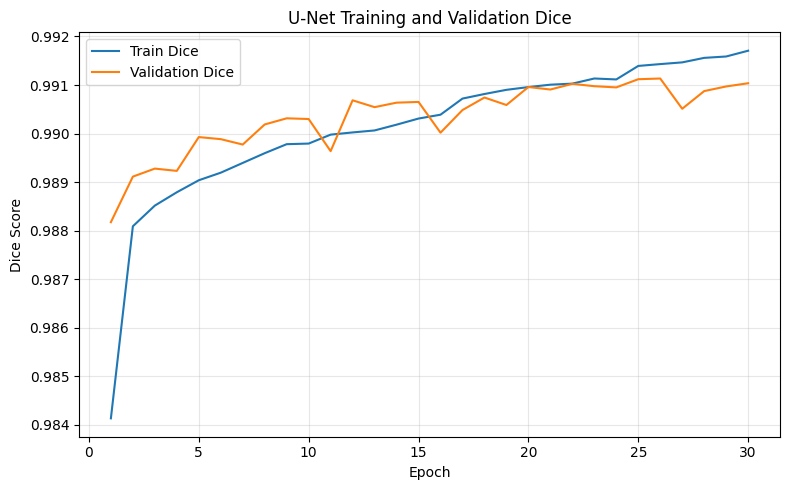

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/dice_curve.png


In [38]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_dice"],
    label="Train Dice"
)

plt.plot(
    history_df["epoch"],
    history_df["val_dice"],
    label="Validation Dice"
)

plt.xlabel("Epoch")
plt.ylabel("Dice Score")

plt.title(
    "U-Net Training and Validation Dice"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()


DICE_CURVE_PATH = (
    RESULTS_DIR /
    "dice_curve.png"
)

plt.savefig(
    DICE_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    DICE_CURVE_PATH
)

# STEP 33 — Plot IoU Curves

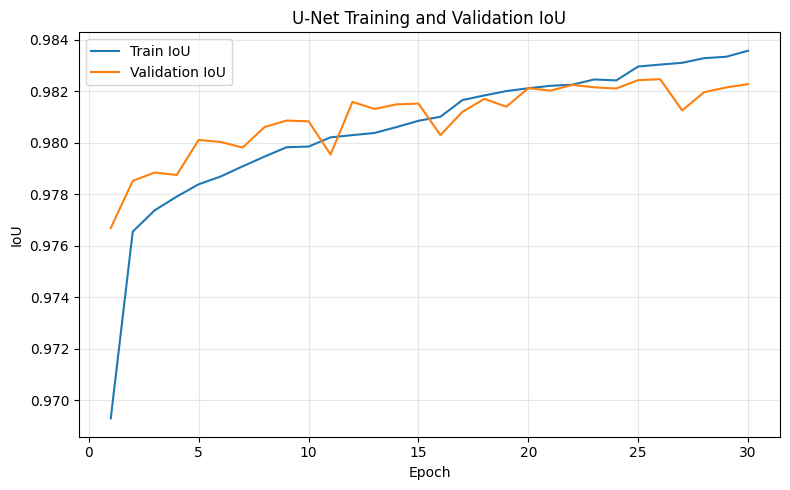

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/iou_curve.png


In [39]:
plt.figure(
    figsize=(8, 5)
)

plt.plot(
    history_df["epoch"],
    history_df["train_iou"],
    label="Train IoU"
)

plt.plot(
    history_df["epoch"],
    history_df["val_iou"],
    label="Validation IoU"
)

plt.xlabel("Epoch")
plt.ylabel("IoU")

plt.title(
    "U-Net Training and Validation IoU"
)

plt.legend()
plt.grid(alpha=0.3)

plt.tight_layout()


IOU_CURVE_PATH = (
    RESULTS_DIR /
    "iou_curve.png"
)

plt.savefig(
    IOU_CURVE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()

print(
    "Saved:",
    IOU_CURVE_PATH
)

# STEP 34 — Visualize Test Predictions

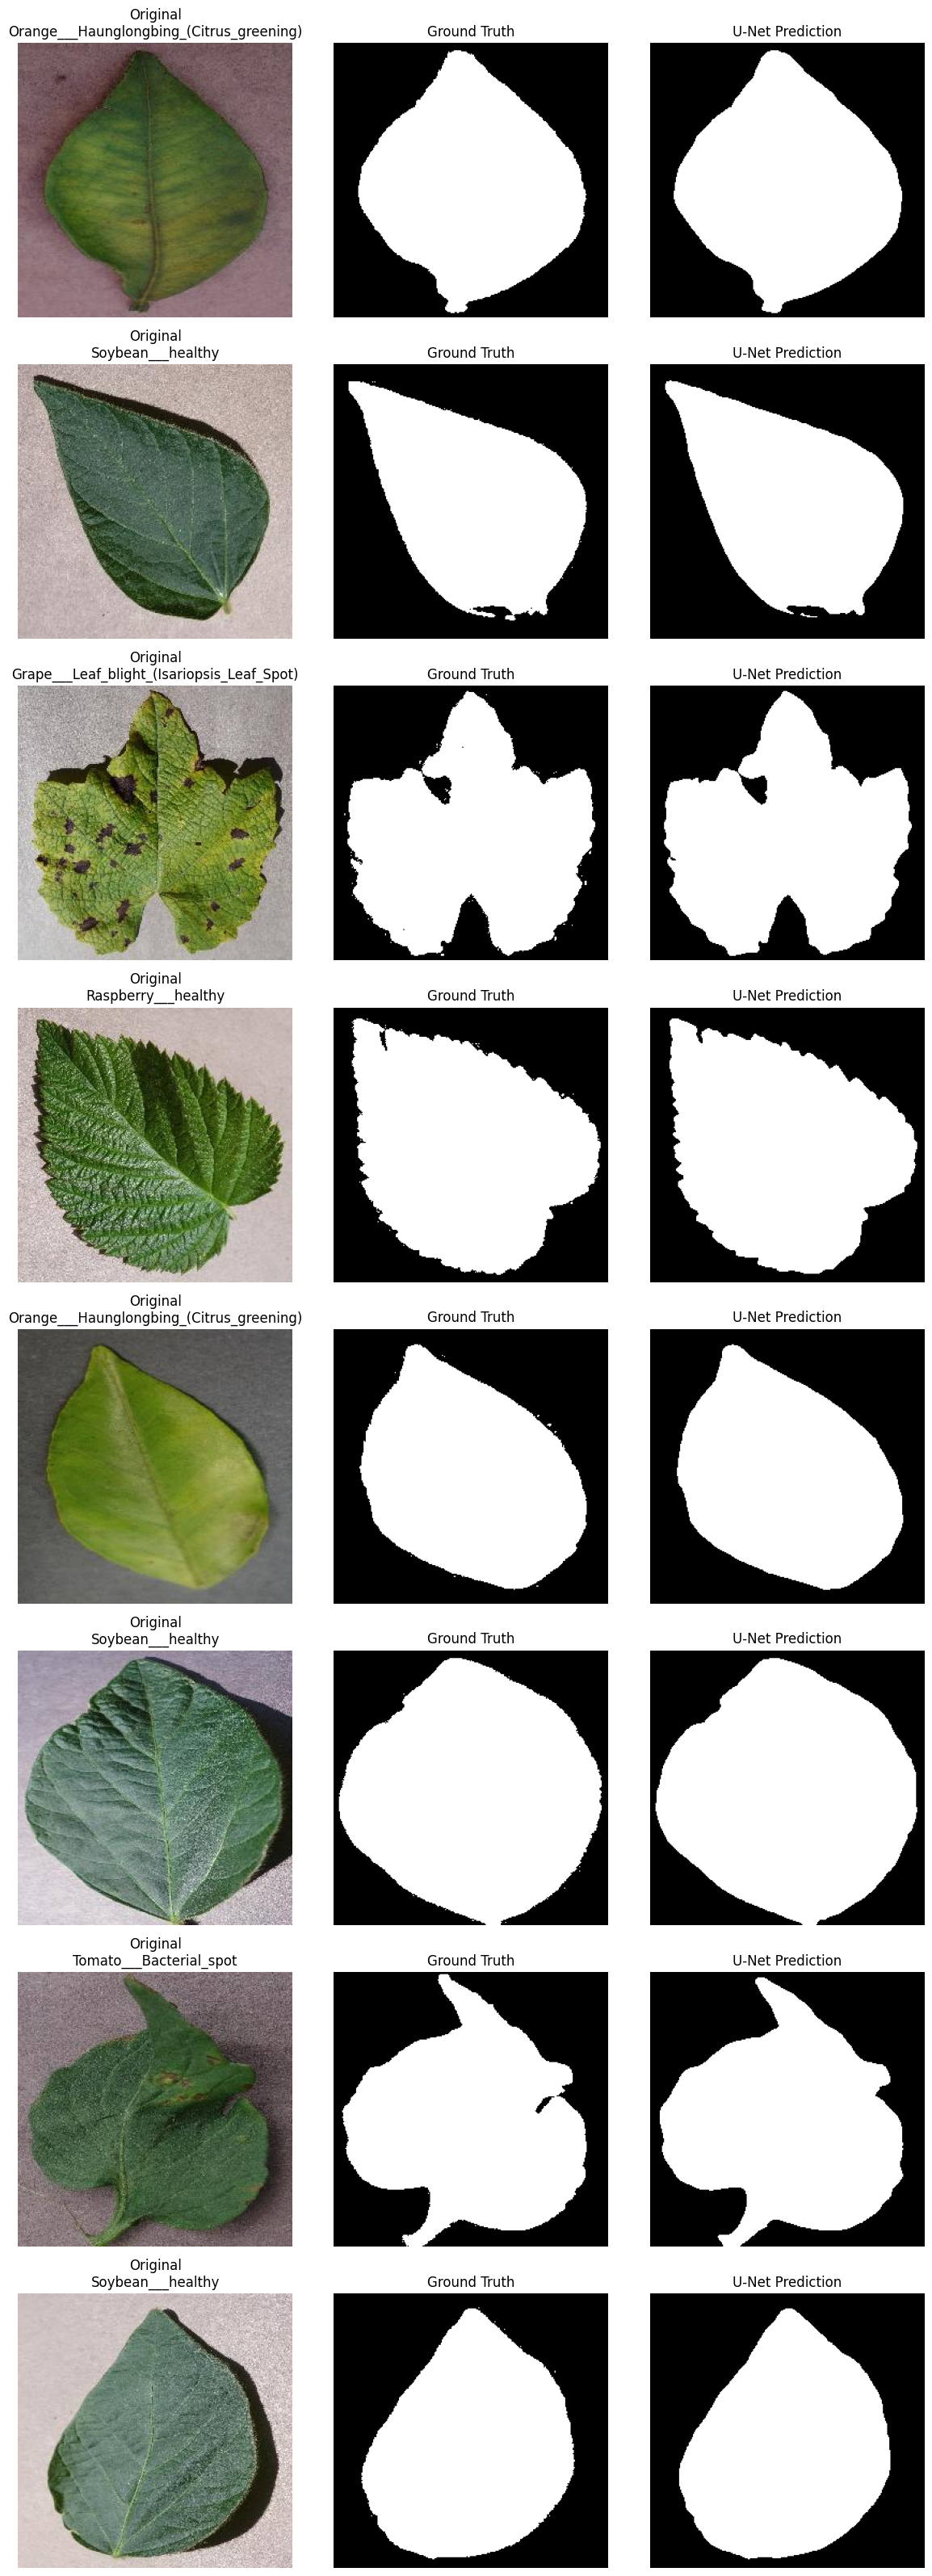

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/predictions/test_predictions.png


In [40]:
random.seed(SEED)

sample_indices = random.sample(
    range(len(test_dataset)),
    8
)


fig, axes = plt.subplots(
    len(sample_indices),
    3,
    figsize=(12, 4 * len(sample_indices))
)


model.eval()


for row_idx, dataset_idx in enumerate(
    sample_indices
):

    sample = test_dataset[
        dataset_idx
    ]


    input_tensor = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )


    with torch.no_grad():

        with torch.amp.autocast(
            device_type=DEVICE.type,
            enabled=(
                DEVICE.type == "cuda"
            )
        ):

            logits = model(
                input_tensor
            )


        probability = torch.sigmoid(
            logits
        )

        prediction = (
            probability >= 0.5
        ).float()


    predicted_mask = (
        prediction[0, 0]
        .cpu()
        .numpy()
    )


    ground_truth = (
        sample["mask"][0]
        .cpu()
        .numpy()
    )


    # Load original RGB directly
    # for clean visualization
    original_image = np.array(
        Image.open(
            dataset_root /
            sample["color_rel"]
        ).convert("RGB")
    )


    axes[row_idx, 0].imshow(
        original_image
    )

    axes[row_idx, 0].set_title(
        f"Original\n"
        f"{sample['class_name']}"
    )

    axes[row_idx, 0].axis("off")


    axes[row_idx, 1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row_idx, 1].set_title(
        "Ground Truth"
    )

    axes[row_idx, 1].axis("off")


    axes[row_idx, 2].imshow(
        predicted_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[row_idx, 2].set_title(
        "U-Net Prediction"
    )

    axes[row_idx, 2].axis("off")


plt.tight_layout()


PREDICTION_FIGURE_PATH = (
    PREDICTION_DIR /
    "test_predictions.png"
)

plt.savefig(
    PREDICTION_FIGURE_PATH,
    dpi=300,
    bbox_inches="tight"
)

plt.show()


print(
    "Saved:",
    PREDICTION_FIGURE_PATH
)

# STEP 35 — Save Individual Prediction Examples

In [41]:
model.eval()

saved_count = 0


for dataset_idx in sample_indices:

    sample = test_dataset[
        dataset_idx
    ]


    image_tensor = (
        sample["image"]
        .unsqueeze(0)
        .to(DEVICE)
    )


    with torch.no_grad():

        logits = model(
            image_tensor
        )

        prediction = (
            torch.sigmoid(logits)
            >= 0.5
        ).float()


    predicted_mask = (
        prediction[0, 0]
        .cpu()
        .numpy()
    )


    ground_truth = (
        sample["mask"][0]
        .cpu()
        .numpy()
    )


    original = np.array(
        Image.open(
            dataset_root /
            sample["color_rel"]
        ).convert("RGB")
    )


    fig, axes = plt.subplots(
        1,
        3,
        figsize=(12, 4)
    )


    axes[0].imshow(original)
    axes[0].set_title("Original")
    axes[0].axis("off")


    axes[1].imshow(
        ground_truth,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[1].set_title(
        "Ground Truth"
    )

    axes[1].axis("off")


    axes[2].imshow(
        predicted_mask,
        cmap="gray",
        vmin=0,
        vmax=1
    )

    axes[2].set_title(
        "U-Net Prediction"
    )

    axes[2].axis("off")


    plt.tight_layout()


    output_path = (
        PREDICTION_DIR /
        f"prediction_{saved_count + 1:02d}.png"
    )


    plt.savefig(
        output_path,
        dpi=300,
        bbox_inches="tight"
    )

    plt.close()


    saved_count += 1


print(
    f"✅ Saved {saved_count} "
    f"prediction figures."
)

✅ Saved 8 prediction figures.


# STEP 36 — Save Complete U-Net Experiment Summary

In [42]:
best_history_row = (
    history_df.loc[
        history_df[
            "val_dice"
        ].idxmax()
    ]
)


experiment_summary = {

    "model":
        "UNet",

    "encoder":
        "resnet34",

    "encoder_pretraining":
        "ImageNet",

    "epochs_completed":
        int(
            history_df[
                "epoch"
            ].max()
        ),

    "best_epoch":
        int(
            best_history_row[
                "epoch"
            ]
        ),

    "best_validation_dice":
        float(
            best_history_row[
                "val_dice"
            ]
        ),

    "best_validation_iou":
        float(
            best_history_row[
                "val_iou"
            ]
        ),

    "final_train_dice":
        float(
            history_df.iloc[-1][
                "train_dice"
            ]
        ),

    "final_validation_dice":
        float(
            history_df.iloc[-1][
                "val_dice"
            ]
        ),

    "training_samples":
        len(train_dataset),

    "validation_samples":
        len(val_dataset),

    "test_samples":
        len(test_dataset),

    "test_metrics":
        test_results,

    "checkpoint":
        str(BEST_MODEL_PATH)
}


SUMMARY_PATH = (
    RESULTS_DIR /
    "experiment_summary.json"
)


with open(
    SUMMARY_PATH,
    "w"
) as f:

    json.dump(
        experiment_summary,
        f,
        indent=4
    )


print(
    "Saved:",
    SUMMARY_PATH
)

print()

print(
    json.dumps(
        experiment_summary,
        indent=2
    )
)

Saved: /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/experiment_summary.json

{
  "model": "UNet",
  "encoder": "resnet34",
  "encoder_pretraining": "ImageNet",
  "epochs_completed": 30,
  "best_epoch": 26,
  "best_validation_dice": 0.9911337333271304,
  "best_validation_iou": 0.9824719366179891,
  "final_train_dice": 0.991706784579744,
  "final_validation_dice": 0.9910363237182778,
  "training_samples": 42371,
  "validation_samples": 5300,
  "test_samples": 5298,
  "test_metrics": {
    "test_loss": 0.0175725767267998,
    "dice": 0.9913193700681049,
    "iou": 0.9827881498379102,
    "precision": 0.9915444042455841,
    "recall": 0.9910944380119033,
    "specificity": 0.9926603931296268,
    "pixel_accuracy": 0.9919325589863657,
    "tp_pixels": 159941085,
    "fp_pixels": 1363930,
    "fn_pixels": 1437164,
    "tn_pixels": 184467549,
    "threshold": 0.5
  },
  "checkpoint": "/content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/checkpoints/be

# STEP 37 — Verify Saved U-Net Files

In [43]:
important_files = [

    BEST_MODEL_PATH,

    LAST_MODEL_PATH,

    HISTORY_PATH,

    TEST_METRICS_PATH,

    TEST_METRICS_CSV,

    LOSS_CURVE_PATH,

    DICE_CURVE_PATH,

    IOU_CURVE_PATH,

    PREDICTION_FIGURE_PATH,

    SUMMARY_PATH
]


print(
    "U-Net experiment files:"
)

print("-" * 60)


for file_path in important_files:

    print(
        "✅"
        if Path(file_path).exists()
        else "❌",
        file_path
    )

U-Net experiment files:
------------------------------------------------------------
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/checkpoints/best_unet.pth
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/checkpoints/last_unet.pth
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/training_history.csv
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/test_metrics.json
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/test_metrics.csv
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/loss_curve.png
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/dice_curve.png
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/results/iou_curve.png
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/predictions/test_predictions.png
✅ /content/drive/MyDrive/PlantVillage_Segmentation/experiments/UNet/re